# Бизнес-контекст

Компания разрабатывает развлекательное приложение с "бесконечной" лентой. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

**Цель эксперимента**

Проверить, увеличивает ли новый алгоритм рекомендаций вовлечённость пользователей.

**Гипотезы**

H0: новый алгоритм не изменяет вероятность успешной сессии

H1: новый алгорит увеличивает вероятность успешной сессии.

# Дизайн эксперимента

**Единица рандомизации**: пользователь.

**Контроль**: группа A, старый алгоритм.

**Тест**: группа B, новый алгоритм.

**Период эксперимента**: 20 дней.

**Ключевая метрика**: доля успешных сессий (в которых пользователь посмотрел >= 4 страниц).

**Критерий успеха**: статистически значимое увеличение метрики в B при уровне значимости = 0.05.


# Параметры эксперимента

- уровень значимости - 0.05

- вероятность ошибки второго рода - 0.2

- минимальный детектируемый эффект (MDE) - 0.03 (допущение проекта)

# Описание данных
Поля таблиц sessions_project_history.csv, sessions_project_test.csv, sessions_project_test_part.csv:

- user_id — идентификатор пользователя;

- session_id — идентификатор сессии в приложении;

- session_date — дата сессии;

- session_start_ts — дата и время начала сессии;

- install_date — дата установки приложения;

- session_number — порядковый номер сессии для конкретного пользователя;

- registration_flag — является ли пользователь зарегистрированным;

- page_counter — количество просмотренных страниц во время сессии;

- region — регион пользователя;

- device — тип устройства пользователя;

- test_group — тестовая группа.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df_history = pd.read_csv('./sessions_project_history.csv')
df_test_part = pd.read_csv('./sessions_project_test_part.csv')
df_test = pd.read_csv('./sessions_project_test.csv')

# Работа с историческими данными

In [8]:
df_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


Рассчитаем количество уникальных сессий для каждого пользователя и выведем пользователя с самым большим количеством сессий.

In [9]:
df_history.groupby('user_id')['session_id'].count().sort_values(ascending=False)

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
D11541BAC141FB94     9
E8ADFF2913E86056     9
FA752AB58040C361     9
                    ..
29643A4DF88AF0CD     1
297264C724CBB558     1
296E7BCDA4004B88     1
296C03E6A6014B36     1
B42D1E6D93C2DCE5     1
Name: session_id, Length: 134039, dtype: int64

In [10]:
df_history[df_history['user_id'] == '10E0DEFC1ABDBBE0']

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


## Анализ количества пользователей по дням

Проанализируем, как менялось число регистраций за всё время существования приложения. Для этого рассчитаем количество уникальных и зарегистрированных пользователей для каждого дня.

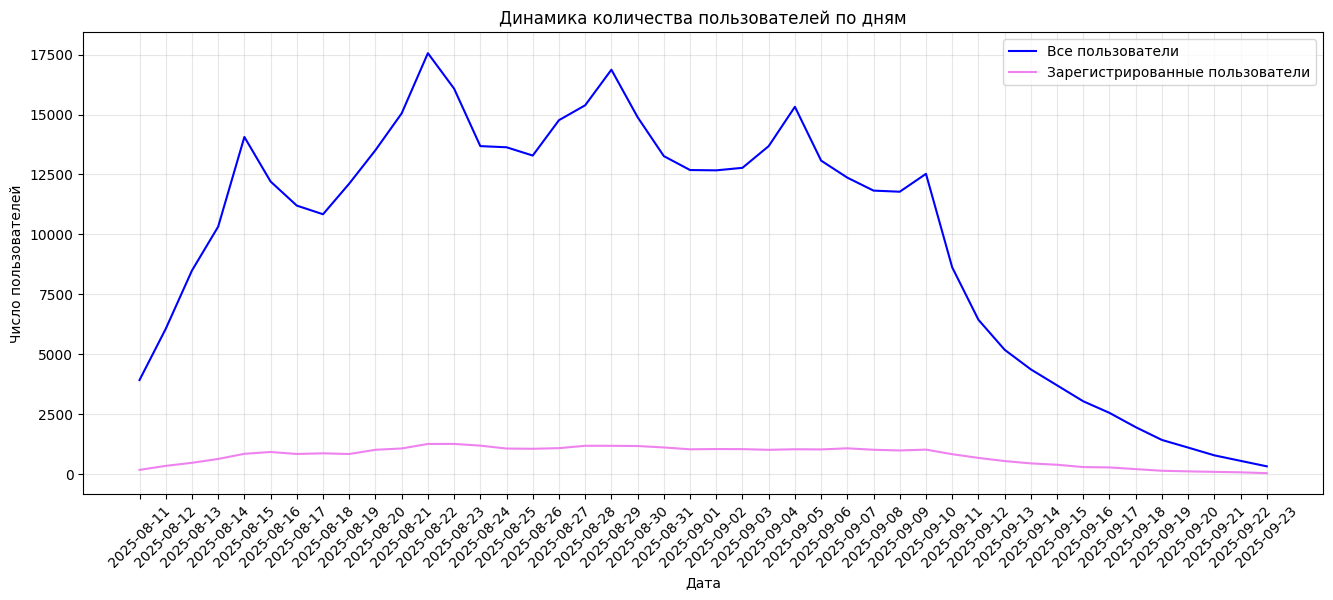

In [11]:
stats = df_history.groupby('session_date').agg(
    total_users = ('user_id', 'nunique'), 
    registered_users = ('registration_flag', 'sum')
    ).reset_index()

plt.figure(figsize=(16, 6))
plt.plot(stats['session_date'],
         stats['total_users'], 
         color='blue',
         label='Все пользователи'
         )
plt.plot(stats['session_date'],
         stats['registered_users'], 
         color='violet',
         label='Зарегистрированные пользователи'
         )
plt.title('Динамика количества пользователей по дням')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.xticks(rotation=45)
plt.grid(alpha = 0.3)
plt.show()

## Анализ количества зарегистрированных пользователей по дням

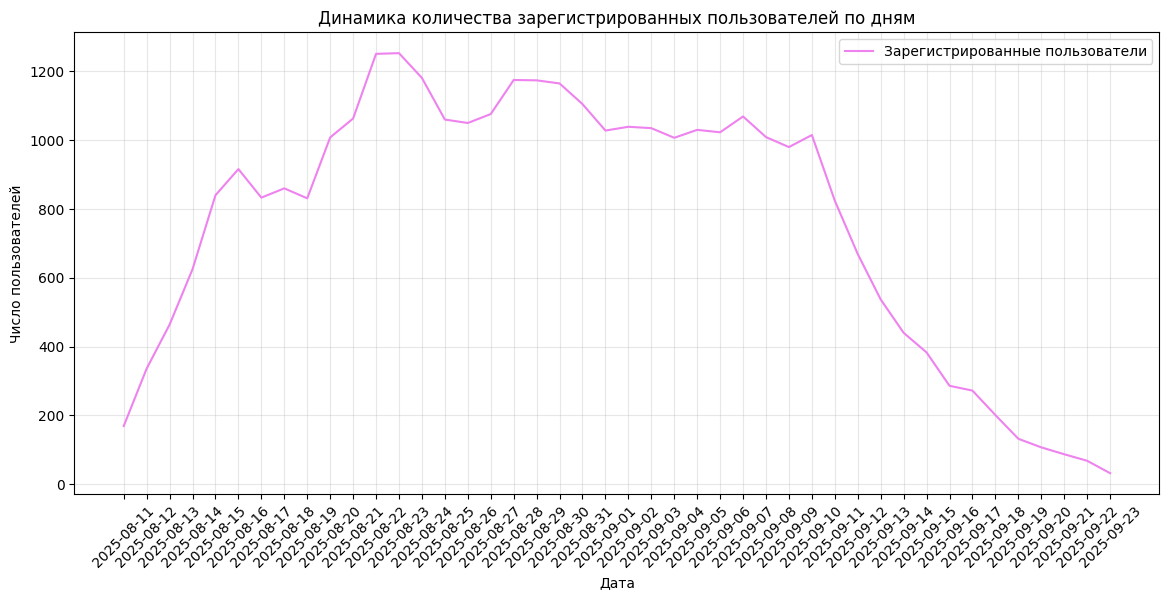

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(stats['session_date'],
         stats['registered_users'], 
         color='violet',
         label='Зарегистрированные пользователи'
         )
plt.title('Динамика количества зарегистрированных пользователей по дням')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

**Наблюдения:**

С 11 августа по 22 августа наблюдается рост как общего количества пользователей, так и зарегистрированных. Затем начинается постепенное снижение с некоторыми промежуточными пиками. С 9 сентября происходит резкое снижение количества в обоих категориях, которое продолжается до конца описанного периода. 
Без дополнительной информации точных причин назвать нельзя, однако можно предположить, что такое поведение в августе вызвано сезонностью, так как целевая аудитория (дети и подростки) имеет больше свободного времени на летних каникулах, которое они предпочитают проводить в приложении. А с началом учебного года перестают заходить так часто.

## Анализ доли зарегистрированных пользователей

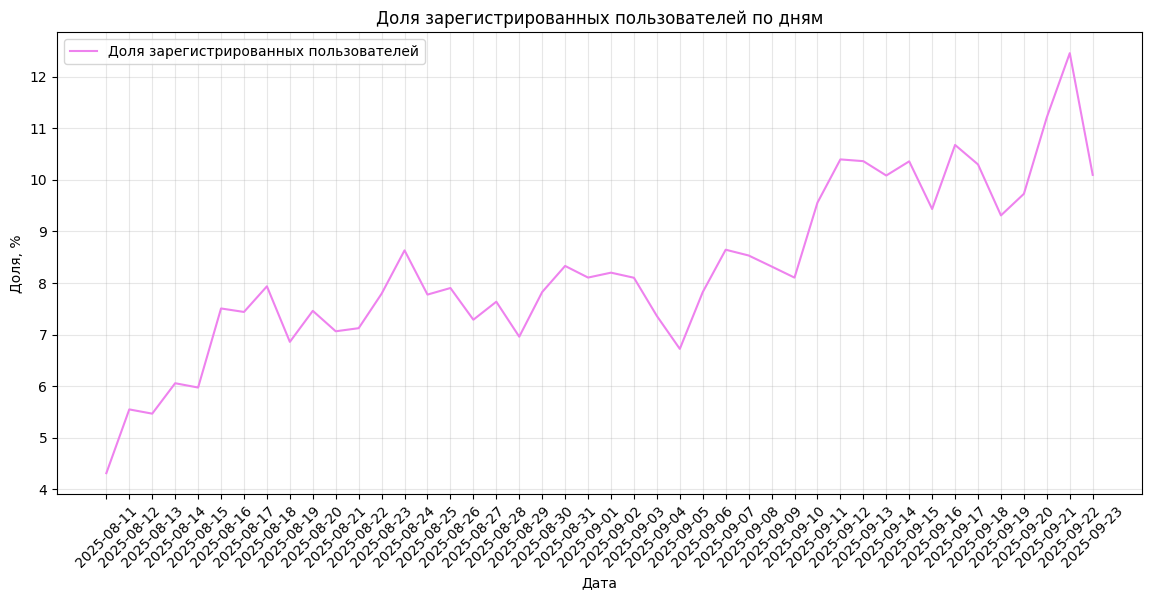

In [13]:
stats['registration_ratio'] = (stats['registered_users'] / stats['total_users']) * 100
plt.figure(figsize=(14, 6))
plt.plot(stats['session_date'],
         stats['registration_ratio'],
         color='violet',
         label='Доля зарегистрированных пользователей')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля, %')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

**Наблюдения:**

Доля зарегистрированных пользователей от общего числа пользователей растёт. Можно заметить, что несмотря на спад активности с 9 сентября, доля регистраций увеличивается.

## Анализ числа просмотренных страниц

Проанализируем количество сессий по числу просмотренных страниц, чтобы понять, насколько пользователи увлечены контентом.

In [14]:
sessions_per_page = df_history.groupby('page_counter').agg({'session_id' : 'count'}).sort_values(by='session_id', ascending = False).reset_index()
sessions_per_page

,page_counter,session_id
0,3,166690
1,4,105569
2,2,105536
3,1,29160
4,5,26288
5,6,2589
6,7,92


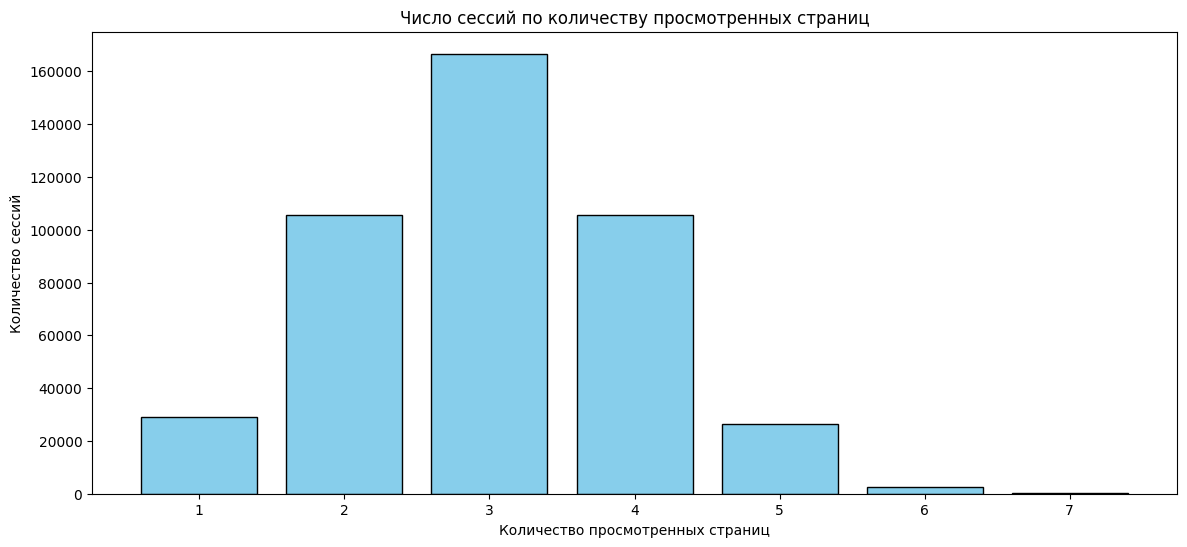

In [15]:
plt.figure(figsize=(14,6))
plt.bar(sessions_per_page['page_counter'], 
        sessions_per_page['session_id'],
        color='skyblue',
        edgecolor='black')
plt.title('Число сессий по количеству просмотренных страниц')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

**Наблюдения:**

Наиболее часто пользователи просматривали 3 страницы за сессию, а затем интерес постепенно терялся. Это может быть вызвано тем, что после 3 страницы начинается просмотр рекламы или предложение приобрести подписку, что отталкивает пользователя от использования приложения.

# Подготовка к A/B-тестированию

In [16]:
from statsmodels.stats.power import NormalIndPower

# задаём параметры
alpha = 0.05
beta = 0.2
power = 1 - beta
mde = 0.03

power_analysis = NormalIndPower()

# рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    alpha=alpha,
    power=power,
    effect_size=mde,
    ratio=1 # равномерное распределение выборок
)

print(f"Размер выборки для каждой группы = {int(sample_size)}")

Размер выборки для каждой группы = 17441


Теперь необходимо рассчитать длительность A/B-теста. Для этого поделим количество пользователей в двух группах на среднее количество пользователей в день.

In [20]:
from math import ceil
# среднее количество активных пользователей в день
avg_daily_users = round(df_history.groupby(pd.to_datetime(df_history['session_date']))['user_id'].nunique().mean())
test_duration = ceil(2*sample_size / avg_daily_users)
print(f"Для среднего количества активных пользователей = {avg_daily_users} понадобится {test_duration} дней")


Для среднего количества активных пользователей = 9907 понадобится 4 дней


# Мониторинг A/B-теста
Данные по A/B тесту за 1 день находятся в df_test_part. Необходимо проверить: равномерно ли распределены пользователи по регионам, устройствам, не пересекаются ли группы

In [24]:
df_test_part.dtypes

user_id              object
session_id           object
session_date         object
session_start_ts     object
install_date         object
session_number        int64
registration_flag     int64
page_counter          int64
region               object
device               object
test_group           object
dtype: object

In [25]:
df_test_part['session_date'] = pd.to_datetime(df_test_part['session_date'])

## Проверка распределения пользователей

In [26]:
df_grp = df_test_part.groupby(['test_group']).agg({'user_id' : 'nunique'}).reset_index()
df_grp

,test_group,user_id
0,A,1477
1,B,1466


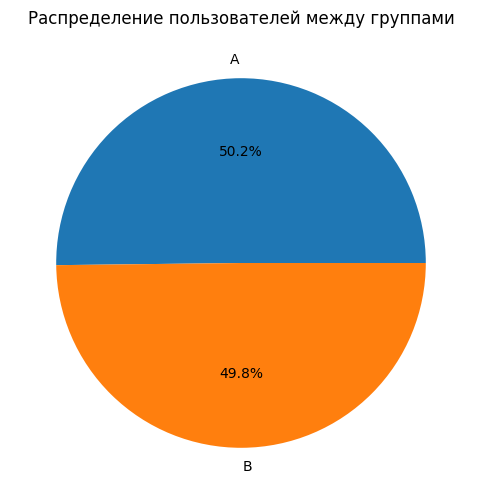

In [32]:
users_a = df_grp[df_grp['test_group'] == 'A'].user_id.values[0]
users_b = df_grp[df_grp['test_group'] == 'B'].user_id.values[0]


plt.figure(figsize=(12, 6))
plt.pie([users_a, users_b], labels=['A', 'B'], autopct='%1.1f%%')
plt.title('Распределение пользователей между группами')
plt.show()

Исходя из визуализации, количество пользователей в группах почти одинаковое. Значит, разделение на группы произошло равномерно по количеству.

## Проверка непересечения групп

In [33]:
users_a = df_grp[df_grp['test_group'] == 'A']['user_id']
users_b = df_grp[df_grp['test_group'] == 'B']['user_id']
intersection = list(set(users_a) & set(users_b))
print(f"Количество пользователей, которые находятся одновременно в двух группах = {len(intersection)}")

Количество пользователей, которые находятся одновременно в двух группах = 0


Пользователей, которые состоят одновременно в двух группах, нет. Следовательно, группы не пересекаются.

## Равномерность распределения пользователей по регионам

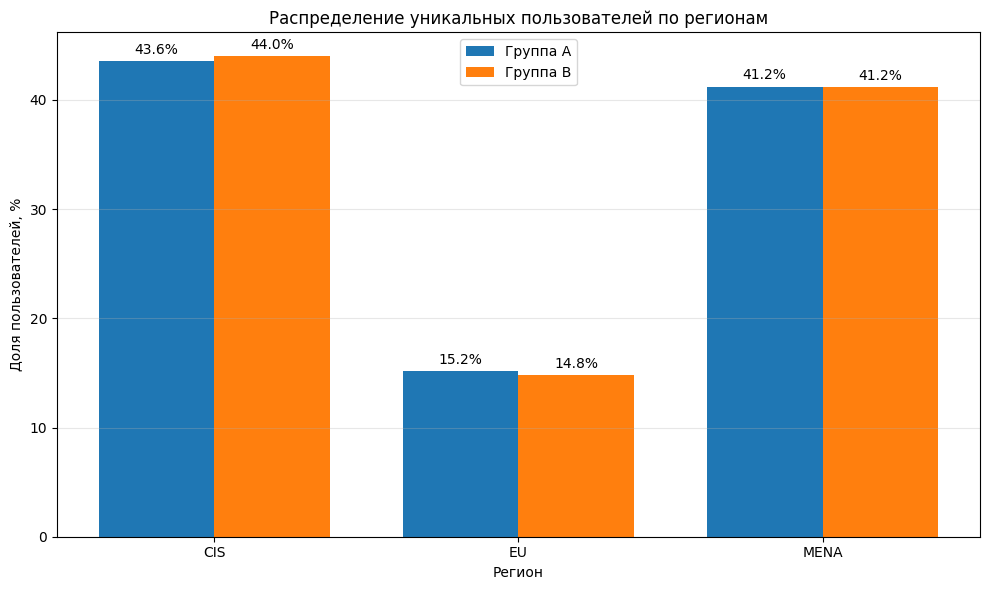

In [ ]:
# Группировка данных по группе и региону
region_distribution = df_test_part.groupby(['test_group', 'region']).agg({'user_id' : 'nunique'})

region_a = region_distribution.loc['A']
region_a_norm = region_a / region_a.sum() * 100
region_b = region_distribution.loc['B']
region_b_norm = region_b / region_b.sum() * 100

regions = region_a_norm.index
x_pos = np.arange(len(regions))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6))
bar_a = ax.bar(x_pos - width / 2, 
               region_a_norm['user_id'], 
               width, 
               label='Группа A')
bar_b = ax.bar(x_pos + width / 2, 
               region_b_norm['user_id'], 
               width, 
               label='Группа B')

ax.set_title('Распределение уникальных пользователей по регионам')
ax.set_xlabel('Регион')
ax.set_ylabel('Доля пользователей, %')
ax.set_xticks(x_pos)
ax.set_xticklabels(regions)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in (bar_a, bar_b):
    ax.bar_label(bars, fmt='%.1f%%', padding=3)

fig.tight_layout()
plt.show()

## Равномерность распределения пользователей по устройствам

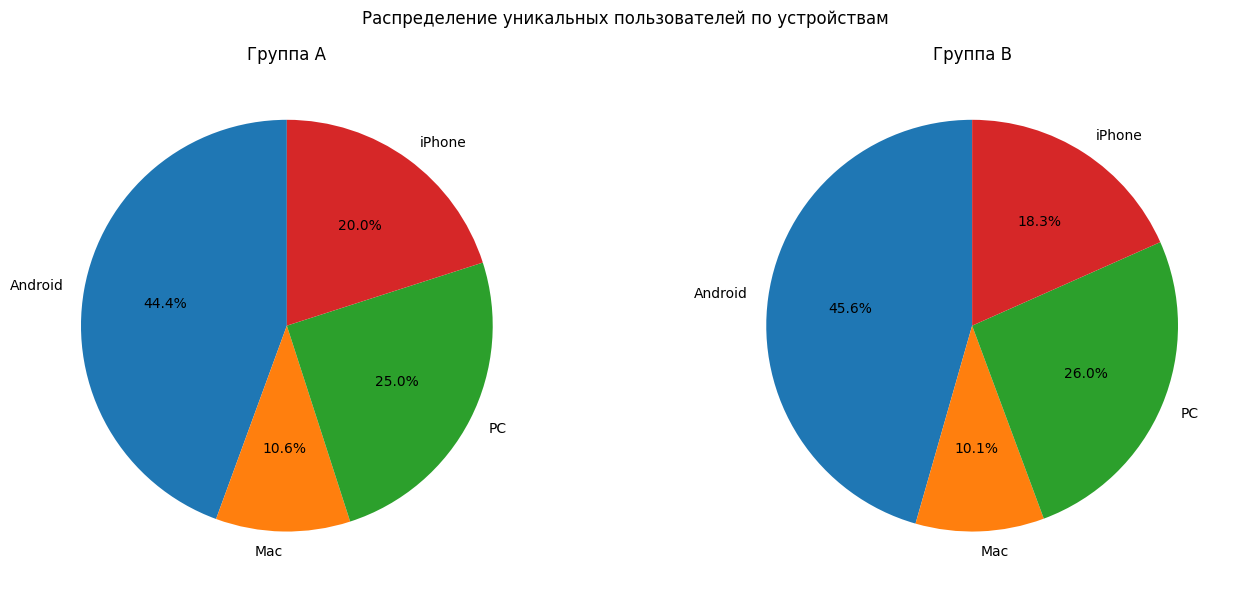

In [65]:
device_distribution = df_test_part.groupby(['test_group', 'device']).agg({'user_id' : 'nunique'})

device_a = device_distribution.loc['A']['user_id']
device_b = device_distribution.loc['B']['user_id']

device_a_norm = device_a / device_a.sum() * 100
device_b_norm = device_b / device_b.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(
    device_a_norm,
    labels=device_a_norm.index,
    autopct='%1.1f%%',
    startangle=90
)
ax1.set_title('Группа A')

ax2.pie(
    device_b_norm,
    labels=device_b_norm.index,
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('Группа B')

fig.suptitle('Распределение уникальных пользователей по устройствам')
fig.tight_layout()
plt.show()

**Выводы:**

- различие в количестве пользователей в двух группах статистически незначимо (менее 1%);

- пересечений между группами не замечено - выборки независимы;

- графики распределения пользователей по регионам и устройствам показали, что распределение по этим признакам равномерное.

Следовательно, A/B-тест организован правильно и его результаты можно считать достоверными.

# Проверка результатов A/B-теста

Сначала проверим, что количество уникальных сессий в двух выборках не различается. Проведём статистический тест для проверки равенства средних двух выборок.

In [66]:
df_test.dtypes

user_id                      object
session_id                   object
session_date         datetime64[ns]
session_start_ts             object
install_date                 object
session_number                int64
registration_flag             int64
page_counter                  int64
region                       object
device                       object
test_group                   object
dtype: object

In [ ]:
# Количество сессий по группам
df_test.groupby(['test_group']).agg({'session_id' : 'count'}).reset_index()

,test_group,session_id
0,A,49551
1,B,50454


In [75]:
daily_sessions = df_test.groupby(['session_date', 'test_group'])['session_id'].nunique().unstack()
daily_sessions.head()

test_group,A,B
session_date,,
2025-10-14,1502,1628
2025-10-15,2235,2283
2025-10-16,3280,3241
2025-10-17,4089,4054
2025-10-18,5013,5059


**Гипотезы для проверки:**
H0 - количество уникальных сессий по дням не различается в группах A и B.

H1 - количество уникальных сессий по дням различается в группах A и B.

Уровень значимости = 0.05

Проверим гипотезы с помощью t-теста.

In [77]:
from scipy.stats import ttest_ind

group_a = daily_sessions['A'].dropna()
group_b = daily_sessions['B'].dropna()

stat, pvalue = ttest_ind(group_a, group_b)
print(f"По результатам теста p-value = {pvalue}")

alpha = 0.05
if pvalue > alpha:
    print("Нулевая гипотеза принимается. Количество уникальных сессий по дням не различается между группами. Тест корректен.")
else:
    print("Принимается альтернативная гипотеза. Количество уникальных сессий по дням различается между группами. ")

По результатам теста p-value = 0.9382193048591161
Нулевая гипотеза принимается. Количество уникальных сессий по дням не различается между группами. Тест корректен.


## Подсчёт целевой метрики

В качестве целевой метрики будем использовать количество успешных сессий. Будем считать сессию успешной, если было просмотрено 4 и более страниц.

In [79]:
df_test['good_session'] = (df_test['page_counter'] >= 4).astype(int)
df_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


In [97]:
# Рассчитаем долю успешных сессий в группах
stats_good = df_test.groupby('test_group')['good_session'].agg(['sum', 'count'])
# Вычислим долю успешных сессий от всех
stats_good['proportion'] = stats_good['sum'] / stats_good['count']
print(f"Доля успешных сессий в группе A = {stats_good['proportion'].loc['A']}")
print(f"Доля успешных сессий в группе B = {stats_good['proportion'].loc['B']}")
#Сравним доли в разных группах
diff = stats_good['proportion'].loc['B'] - stats_good['proportion'].loc['A']
print(f"Разница в долях успешных сессий в группах A и B = {diff}")

Доля успешных сессий в группе A = 0.3077233557344958
Доля успешных сессий в группе B = 0.31828992745867524
Разница в долях успешных сессий в группах A и B = 0.010566571724179463


Рассчитаем, является ли изменение метрики статистически значимым с помощью Z-теста пропорций.

H0: вероятности успешной сессии в двух группах равны.

H1: вероятность успешной сессии в группе A меньше, чем в группе B.

Уровень значимости = 0.05

In [96]:

from statsmodels.stats.proportion import proportions_ztest
m = [stats_good.loc['A', 'sum'], stats_good.loc['B', 'sum']] # число успехов
n = [stats_good.loc['A', 'count'], stats_good.loc['B', 'count']] # общее число экспериментов

z, pvalue = proportions_ztest(m, n, alternative='smaller')
alpha = 0.05
if (z < 0) and (pvalue < alpha):
    print(f"Z = {z} < 0 и p-value = {pvalue} < 0.05. Следовательно вероятность успешной сессиии в группе B больше, чем в группе A.")
else:
    print("Разница в долях успешных сессий группы A и группы B статистически незначима.")


Z = -3.602684259949491 < 0 и p-value = 0.0001574739988036123 < 0.05. Следовательно вероятность успешной сессиии в группе B больше, чем в группе A.


По результатам статистического теста выяснилось, что различие ключевой метрики между группами статистически значимо. 

- Z = -3,603 является отрицательным числом. Это говорит о том, что вероятность успеха в группе B больше, чем вероятность в группе A.

- p-value = 0.001. При справедливости нулевой гипотезы вероятность получить наблюдаемое или более экстремальное различие составляет около 0,1%. Поэтому нулевая гипотеза отвергается на уровне значимости 5%.

Однако сам прирост метрики в группе B составил лишь +1,06%, что может быть недостаточным для бизнеса.

# Вывод


**1. Характеристики эксперимента:**

- *Распределение по группам*: группа A = 49551 сессий, группа B = 50454 сессий

- *Продолжительность теста*: 20 дней

- *Ключевая метрика*: доля успешных сессий (критерий: page_counter >= 4)

**2. Влияние нового алгоритма рекомендаций на рост ключевой метрики:**

- *Метрика в группе A (старый алгоритм)*: 30,77% успешных сессий

- *Метрика в группе B (новый алгоритм)*: 31,83% успешных сессий

- *Абсолютный прирост*: 1,06%

Новый алгоритм увеличил долю успешных сессий, что говорит о росте вовлечённости пользователей. Однако прирост не такой большой, как мог бы быть, и может быть недостаточным для бизнеса.

**3. Оценка статистической значимости:**

- *p-value* = 0.001

- Разница ключевой метрики в группах статистически *значима*, а вероятность случайного отклонения < *0,1%*.

**4. Рекомендации:**

- Новый алгоритм статистически значимо увеличил долю успешных сессий на 1,06%. Однако эффект относительно небольшой и находится около установленного MDE. Перед полным переходом на новый алгоритм рекомендуется оценить экономический эффект, проверить устойчивость результата по ключевым сегментам и провести длительный эксперимент для оценки retention-метрик.
